In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
import sympy
from sympy import factorial, Rational, symbols, exp, simplify, integrate, solve, oo, pi, expand, sqrt,  erf, latex
# from sympy.stats import Gamma
from spb import plot, plot3d_parametric_surface, PB

In [15]:
import warnings
warnings.filterwarnings('ignore')

# Gamma Distribution

In [4]:
from scipy.stats import gamma

## Introduction

The **Gamma distribution** is a two-parameter ($\alpha, \beta$) family of continuous probability distributions, often used to model waiting times or non-negative, skewed data.

The parameter $\alpha$ (or $k$) is known as the **shape parameter**, and the parameter $\beta$ (or $\lambda$) is called the **rate parameter** ($\theta=1/\beta$ is called **scale parameter**). 

When both parameters are integers, the **Gamma Distribution** becomes a **Gamma Process**, often used in the analysis of the lifetimes of systems or events.

## $\Gamma$ function

The **gamma function**, denoted as $\Gamma (z)$, is a generalization of the factorial function to real and complex numbers. 

It is defined by the integral 

$$\Gamma (z)=\int_{0}^{\infty}t^{z-1}e^{-t}dt$$

for complex numbers with a positive real part. 

For a positive integer $n$, $\Gamma (n+1)=n!$, and the function satisfies the property $\Gamma (z+1)=z\Gamma (z)$.

In [6]:
x = symbols('x', real=True)
gamma(Rational(1, 2))

sqrt(pi)

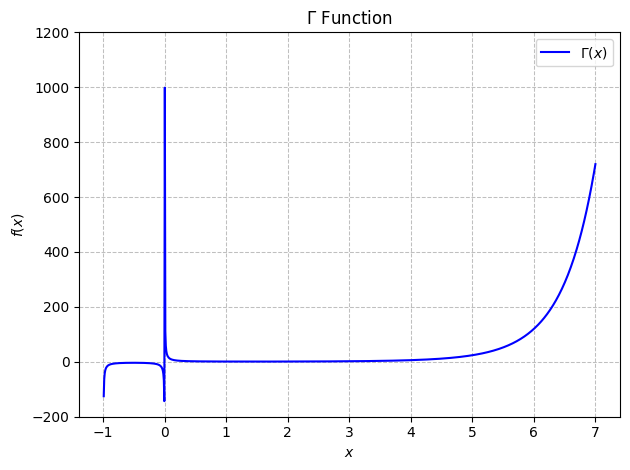

In [7]:
p1 = plot(gamma(x), (x, -1, 7), ylim=(-200,1200), line_color='blue', show=False, 
    title="$\Gamma$ Function", legend=True)
p1.show()

## Generating

In [5]:
a, b = 5, 1/2 # a -- shape, b -- rate

In [14]:
# Generate some synthetic data
samples = gamma.rvs(a=a, scale=1/b, size=1000)

# Fit the Gamma distribution to the data
shape, loc, scale = gamma.fit(samples)

print(f"Fitted shape (α): {shape:.2f}")
print(f"Fitted scale (θ or 1/β): {scale:.2f}")

Fitted shape (α): 4.79
Fitted scale (θ or 1/β): 2.02


## Distribution

In [7]:
a, b = 5, 1/2 # a -- shape, b -- rate

### Probability Density Function (`.pdf`)

#### Intro

A random variable $X$ has a gamma distribution with parameters $\alpha, \beta >0$, if $X$ has **pdf** given by

$$
f(x) = 
\begin{cases}
\frac{\beta^{\alpha}}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x},& \ \mathrm{for} \ x\geq 0\\
0,& \ \mathrm{otherwise}\\
\end{cases}
$$

In [ ]:
x, y, alpha, beta, lambd, k = symbols('x y alpha beta lambda k', real=True, positive=True)

pdf = beta**alpha * x**(alpha-1) * exp(-beta*x)/sympy.gamma(alpha)

display(pdf)
print(gamma.pdf(9, a, scale=1/b), 
      pdf.subs([(x, 9), (beta, b), (alpha, a)]), 
      pdf.evalf(subs={x: 9, beta: b, alpha: a}))

beta**alpha*x**(alpha - 1)*exp(-beta*x)/gamma(alpha)

0.09490381027006223 0.0949038102700622 0.0949038102700622


#### Connection to Poisson Distribution

The **Poisson** and **Gamma** distributions are fundamentally linked: 
- the **Poisson distribution** models the number of random events ($k$) occurring within a fixed interval (discrete), 
- while the **Gamma distribution** models the waiting time ($x$) until a specific number ($\alpha$) of those events occur (continuous). 

In [10]:
pmfPoisson = lambd**k * exp(-lambd)/factorial(k)
pmfPoisson

lambda**k*exp(-lambda)/factorial(k)

In [33]:
display(pdf.evalf(subs={alpha:k, beta:lambd, x:1})/k)
simplify((pdf.evalf(subs={alpha:k, beta:lambd, x:1})/k)/pmfPoisson)

lambda**k*exp(-lambda)/(k*gamma(k))

1

### Cumulative Distribution Function (`.cdf`)

In [28]:
# Compute the indefinite integral of the expression f with respect to x
cdf = integrate(pdf, (x, 0, y))
simplify(cdf)

lowergamma(alpha, beta*y)/gamma(alpha)

In [ ]:
# gamma.cdf(4, a=a, scale=1/b)
xValue = 9
display(pdf)
print(gamma.pdf(xValue, a, scale=1/b), 
      pdf.evalf(subs={x: xValue, beta: b, alpha: a}))

beta**alpha*x**(alpha - 1)*exp(-beta*x)/gamma(alpha)

0.09490381027006223 0.0949038102700622 0.0949038102700622


### Quantiles (`.ppf`)

In [ ]:
p0 = symbols('p0', real=True, positive=True)
ppf = simplify(solve(cdf-p0, y)[0])
print(ppf)

In [20]:
gamma.ppf(0.3, a=a, scale=1/b)

np.float64(7.267218165927605)

### Mean or expected value (`.mean`)

In [22]:
# Compute the mean integral of the expression fx with respect to x
mean = simplify(integrate(pdf*x, (x, 0, oo)))
mean

alpha/beta

In [ ]:
# xValue = 9
display(mean)
print(gamma.mean( a, scale=1/b), 
      mean.evalf(subs={x: xValue, beta: b, alpha: a}))

alpha/beta

10.0 10.0000000000000 10.0000000000000


### Variances (`.var`) and Standard Deviation (`.std`)

In [32]:
var = simplify(integrate(pdf*(x-mean)**2, (x, 0, oo)))
var

alpha/beta**2

In [ ]:
xValue = 9
display(var)
print(gamma.var( a, scale=1/b), 
      var.evalf(subs={x: xValue, beta: b, alpha: a}))

alpha/beta**2

20.0 20.0000000000000 20.0000000000000


In [27]:
std = simplify(sqrt(var))
std

sqrt(alpha)/beta

In [ ]:
xValue = 9
display(std)
print(gamma.std( a, scale=1/b), 
      std.evalf(subs={x: xValue, beta: b, alpha: a}))

sqrt(alpha)/beta

4.47213595499958 4.47213595499958 4.47213595499958


## Visualization

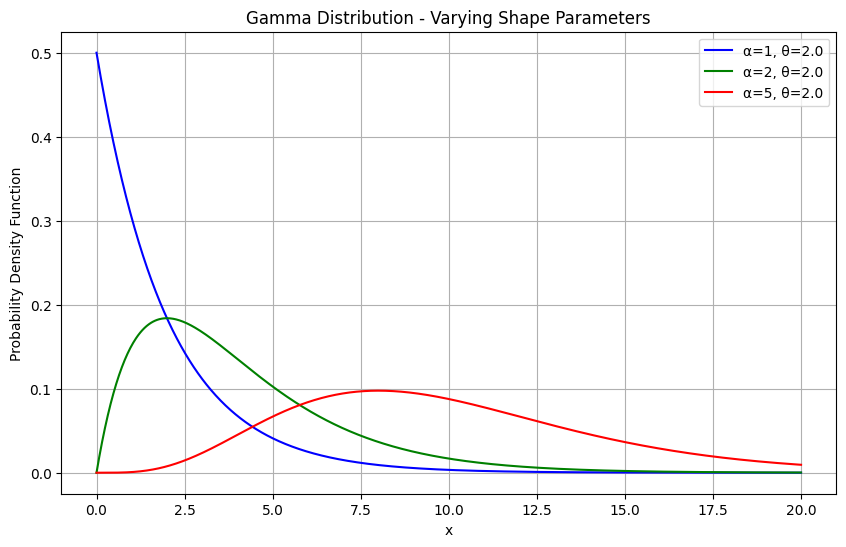

In [ ]:
xValues = np.linspace(0, 20, 1000)

# Shape parameters
shapes = [1, 2, 5]
colors = ['blue', 'green', 'red']

plt.figure(figsize=(10, 6))

for aa, color in zip(shapes, colors):
    plt.plot(xValues, gamma.pdf(x, a=aa, scale=1/b), label=f'α={aa}, θ={1/b}', color=color)

plt.title('Gamma Distribution - Varying Shape Parameters')
plt.xlabel('x')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()

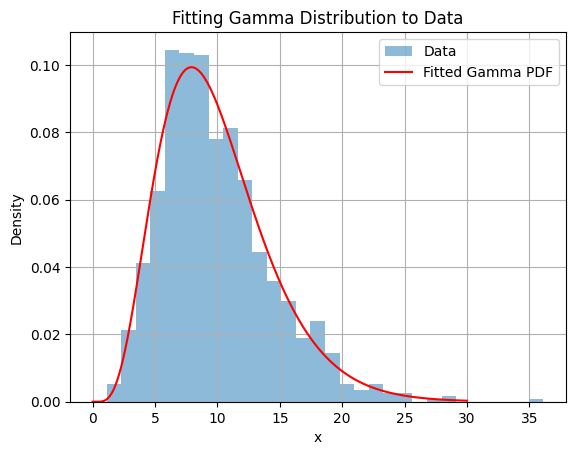

In [ ]:
# Create a range of x-values for the plot
xValues = np.linspace(0, 30, 1000)
pdf_fitted = gamma.pdf(xValues, a=shape, loc=loc, scale=scale)

# Plot histogram and fitted curve
plt.hist(samples, bins=30, density=True, alpha=0.5, label='Data')
plt.plot(xValues, pdf_fitted, 'r-', label='Fitted Gamma PDF')
plt.title('Fitting Gamma Distribution to Data')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

## References

- [Gamma Distribution](https://allen.in/jee/maths/gamma-distribution)
- [Gamma Distribution with Python](https://medium.com/data-bistrot/gamma-distribution-with-python-f84f671a8b97)
- [Gamma distribution and Poisson distribution](https://statisticalmodeling.wordpress.com/2018/10/25/gamma-distribution-and-poisson-distribution/)